# TP DSP - Grupo 5: Filtrado e Identificación de Sistemas

## Introducción

Un analizador de doble canal analiza simultáneamente la entrada y salida de un sistema 
para caracterizarlo en frecuencia. La respuesta en frecuencia H(ω) se obtiene como:

$$H(\omega) = \frac{Y(\omega)}{X(\omega)}$$

donde Y(ω) y X(ω) son las transformadas de Fourier de la salida y entrada respectivamente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funciones import *

%matplotlib inline

## Parte 1: Herramientas de análisis

### 1. Generación y graficación de señales

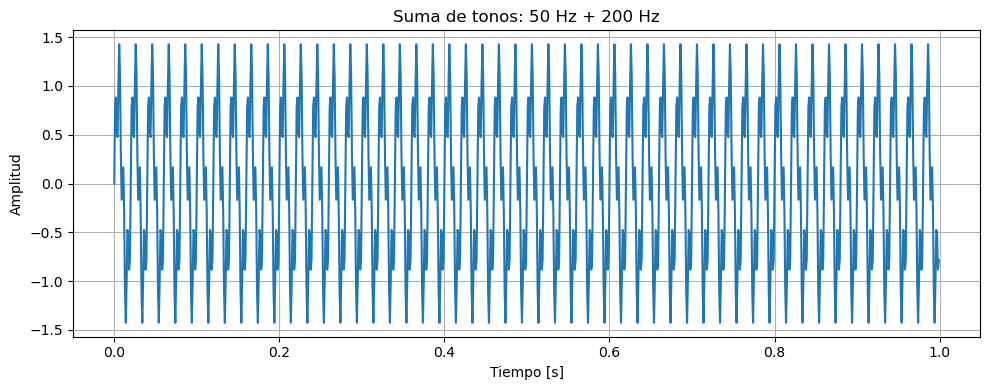

In [2]:
# Parámetros
fs = 1000       # frecuencia de muestreo: 1000 Hz
duracion = 1    # 1 segundo

# Generamos una suma de tonos puros: 50 Hz y 200 Hz
senal = generar_suma_tonos(
    frecuencias=[50, 200],
    amplitudes=[1, 0.5],
    fs=fs,
    duracion=duracion
)

# Graficamos la señal temporal
graficar_senal(senal, fs=fs, titulo="Suma de tonos: 50 Hz + 200 Hz")

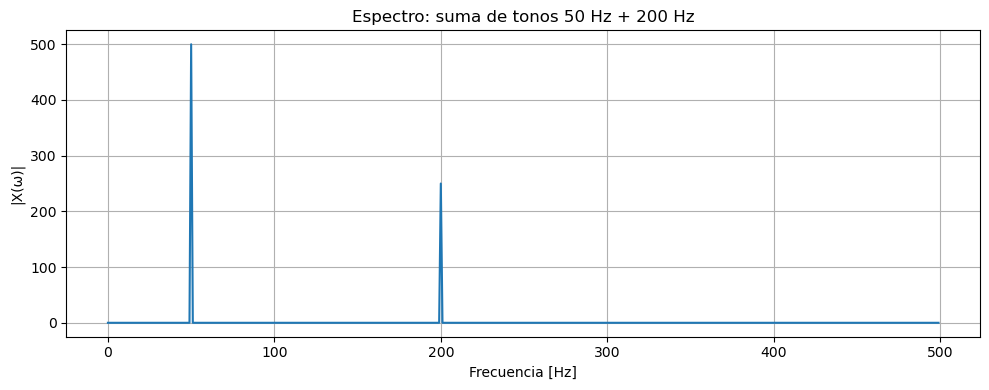

In [3]:
# Graficamos el espectro de la misma señal
graficar_espectro(senal, fs=fs, titulo="Espectro: suma de tonos 50 Hz + 200 Hz")

Los dos picos en el espectro corresponden exactamente a las frecuencias de los tonos 
generados (50 Hz y 200 Hz), con amplitudes proporcionales a las indicadas (1 y 0.5 
respectivamente). Esto confirma que la FFT identifica correctamente las componentes 
frecuenciales de la señal.

### 2. Señal con ruido blanco

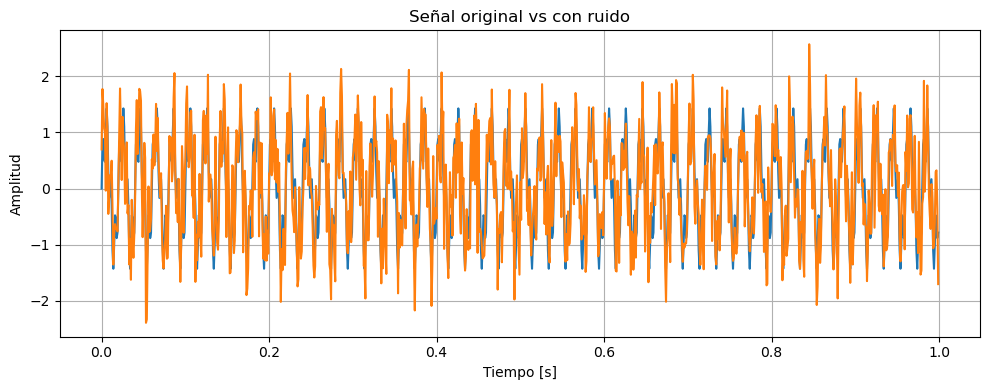

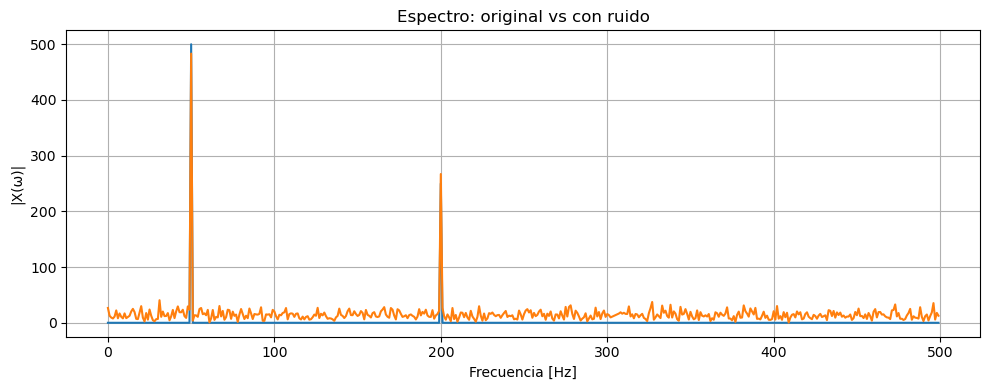

In [4]:
# Agregamos ruido blanco a la señal
senal_con_ruido = agregar_ruido_blanco(senal, amplitud=0.5)

# Comparamos temporal
graficar_senal([senal, senal_con_ruido], fs=fs, titulo="Señal original vs con ruido")

# Comparamos espectros
graficar_espectro([senal, senal_con_ruido], fs=fs, titulo="Espectro: original vs con ruido")

### Observación

Al agregar ruido blanco, en el dominio temporal la señal se ve "sucia" pero todavía 
se reconoce la forma original. En el espectro, el efecto es más revelador: el ruido 
blanco distribuye energía en **todas las frecuencias** de manera uniforme, lo que se 
manifiesta como un "piso" de perturbaciones a lo largo de todo el espectro, en lugar 
de los dos picos limpios de la señal original.

Esto ilustra una propiedad fundamental del ruido blanco: su densidad espectral de 
potencia es constante en todas las frecuencias.

### 3. Filtros y respuesta al impulso

Analizamos los tres filtros requeridos: media móvil, peine y FIR.

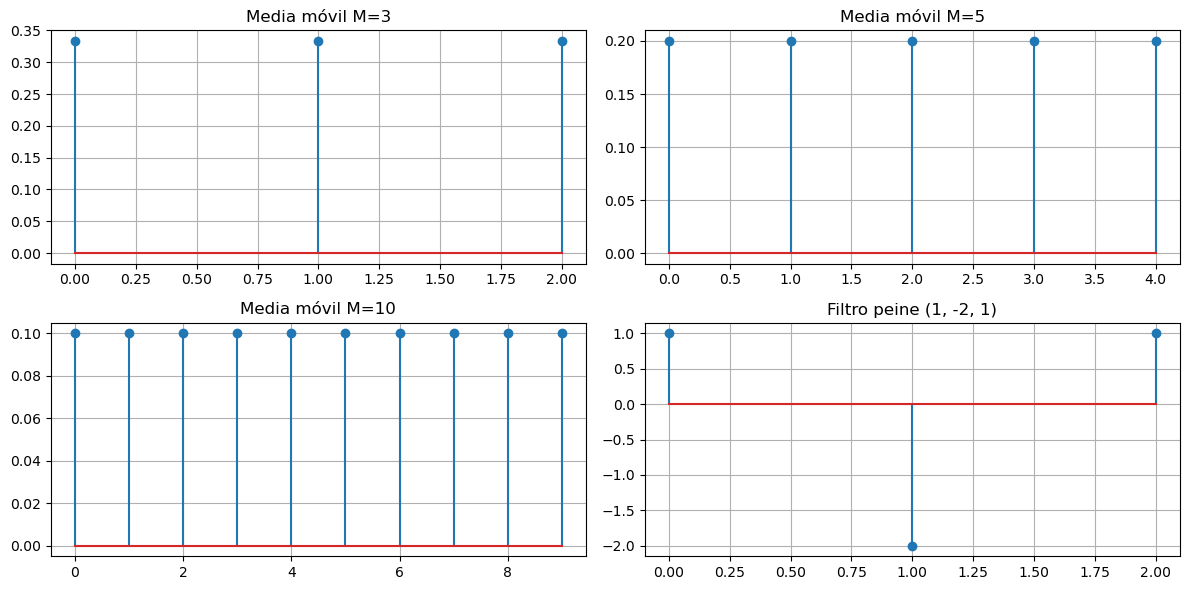

In [5]:
# Generamos las respuestas al impulso de cada filtro
h_mm3  = filtro_media_movil(M=3)   # media móvil con 3 puntos
h_mm5  = filtro_media_movil(M=5)   # media móvil con 5 puntos
h_mm10 = filtro_media_movil(M=10)  # media móvil con 10 puntos

h_peine = filtro_peine(b0=1, b1=-2, b2=1)  # un ejemplo de filtro peine

# Graficamos las respuestas al impulso
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0,0].stem(h_mm3)
axes[0,0].set_title("Media móvil M=3")
axes[0,0].grid(True)

axes[0,1].stem(h_mm5)
axes[0,1].set_title("Media móvil M=5")
axes[0,1].grid(True)

axes[1,0].stem(h_mm10)
axes[1,0].set_title("Media móvil M=10")
axes[1,0].grid(True)

axes[1,1].stem(h_peine)
axes[1,1].set_title("Filtro peine (1, -2, 1)")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

### 4. Caracterización en frecuencia de los filtros (módulo y fase)

Para analizar el comportamiento de cada filtro en frecuencia, calculamos su respuesta 
en frecuencia H(ω) aplicando el filtro a un impulso y luego calculando la FFT.

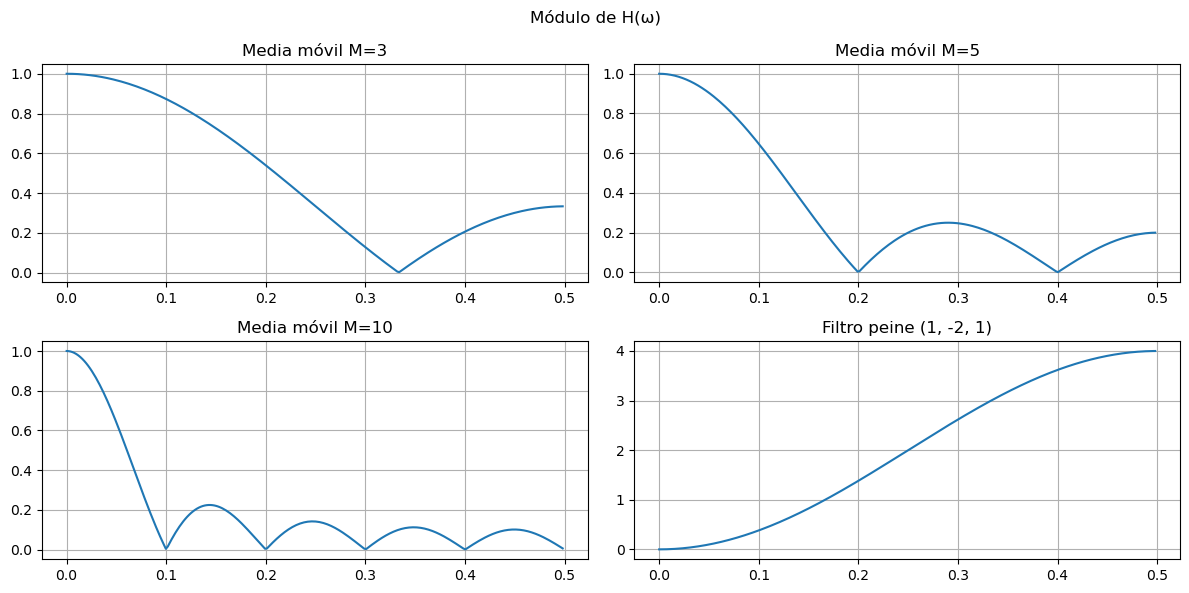

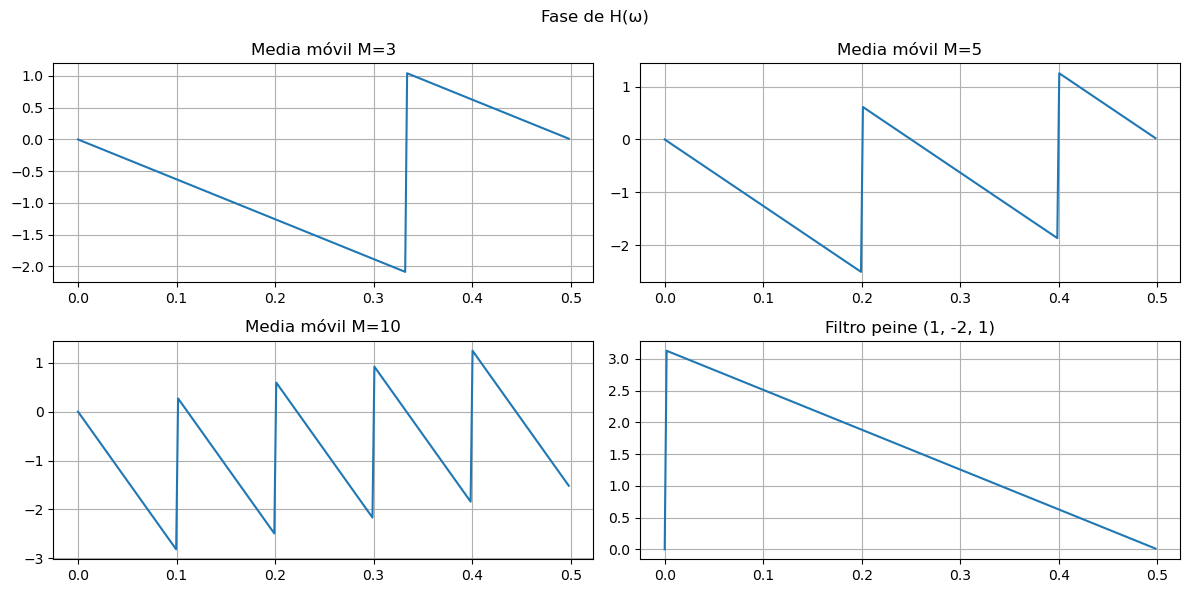

In [6]:
# Creamos un impulso para calcular H(ω) de cada filtro
N = 512  # longitud del impulso (potencia de 2 para eficiencia de la FFT)
impulso = np.zeros(N)
impulso[0] = 1

# Calculamos H(ω) para cada filtro convolucionando con el impulso
y_mm3   = filtrar_convolucion(impulso, h_mm3)[:N]
y_mm5   = filtrar_convolucion(impulso, h_mm5)[:N]
y_mm10  = filtrar_convolucion(impulso, h_mm10)[:N]
y_peine = filtrar_convolucion(impulso, h_peine)[:N]

H_mm3,   freqs = calcular_H(impulso, y_mm3)
H_mm5,   _     = calcular_H(impulso, y_mm5)
H_mm10,  _     = calcular_H(impulso, y_mm10)
H_peine, _     = calcular_H(impulso, y_peine)

mitad = N // 2

# Módulo
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle("Módulo de H(ω)")

axes[0,0].plot(freqs[:mitad], np.abs(H_mm3[:mitad]))
axes[0,0].set_title("Media móvil M=3")
axes[0,0].grid(True)

axes[0,1].plot(freqs[:mitad], np.abs(H_mm5[:mitad]))
axes[0,1].set_title("Media móvil M=5")
axes[0,1].grid(True)

axes[1,0].plot(freqs[:mitad], np.abs(H_mm10[:mitad]))
axes[1,0].set_title("Media móvil M=10")
axes[1,0].grid(True)

axes[1,1].plot(freqs[:mitad], np.abs(H_peine[:mitad]))
axes[1,1].set_title("Filtro peine (1, -2, 1)")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Fase
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle("Fase de H(ω)")

axes[0,0].plot(freqs[:mitad], np.angle(H_mm3[:mitad]))
axes[0,0].set_title("Media móvil M=3")
axes[0,0].grid(True)

axes[0,1].plot(freqs[:mitad], np.angle(H_mm5[:mitad]))
axes[0,1].set_title("Media móvil M=5")
axes[0,1].grid(True)

axes[1,0].plot(freqs[:mitad], np.angle(H_mm10[:mitad]))
axes[1,0].set_title("Media móvil M=10")
axes[1,0].grid(True)

axes[1,1].plot(freqs[:mitad], np.angle(H_peine[:mitad]))
axes[1,1].set_title("Filtro peine (1, -2, 1)")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

### Observación: efecto del parámetro M en el filtro media móvil

El módulo de H(ω) confirma que la media móvil es un filtro **pasa-bajos**: deja pasar 
las bajas frecuencias y atenúa las altas. A medida que aumenta M:
- El lóbulo principal se vuelve más angosto → mayor selectividad en frecuencia
- La atenuación en las frecuencias altas es mayor
- Sin embargo, también aparecen lóbulos secundarios más pronunciados

La fase lineal es una propiedad característica de todos los filtros FIR simétricos: 
significa que todas las frecuencias se retrasan la misma cantidad de tiempo, 
preservando la forma de la señal.

### 5. Filtrado de la señal con ruido (MEDIA MOVIL)

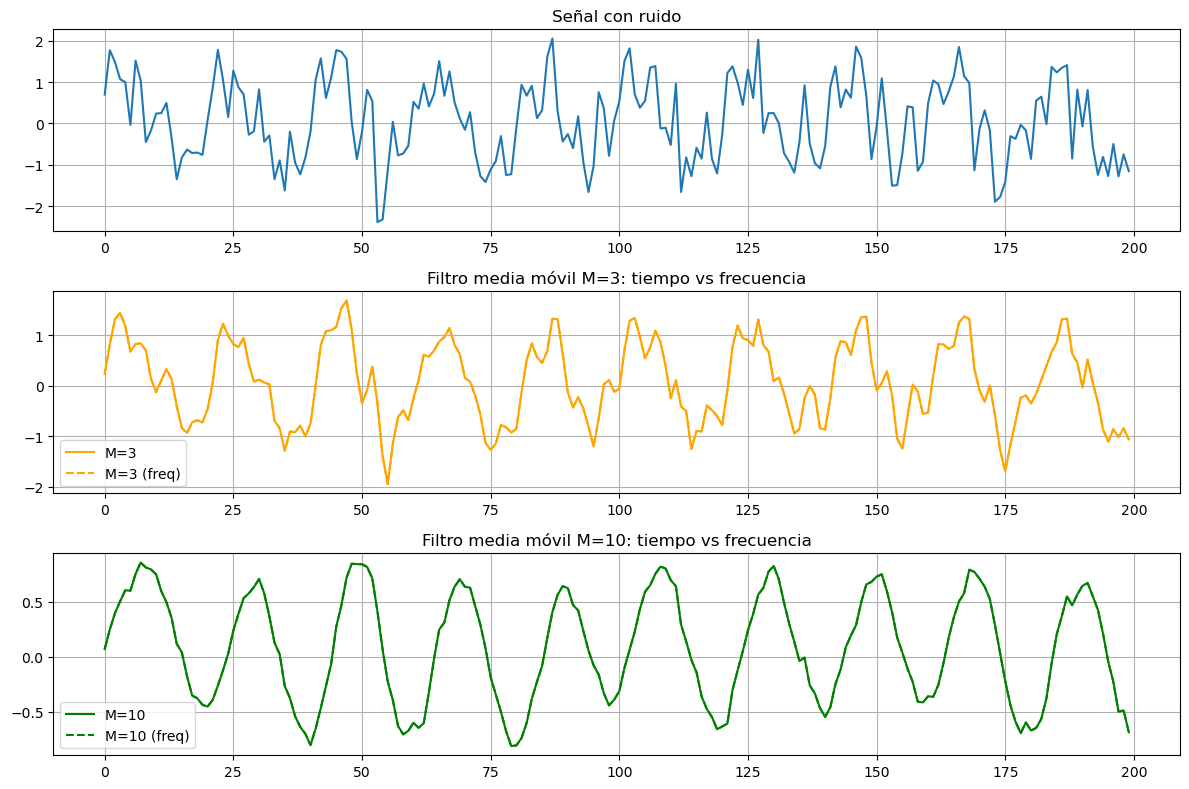

In [7]:
# Filtramos la señal con ruido usando los tres filtros de media móvil
# Usamos ambos métodos: convolución temporal y convolución circular en frecuencia

y_mm3_tiempo    = filtrar_convolucion(senal_con_ruido, h_mm3)[:len(senal_con_ruido)]
y_mm10_tiempo   = filtrar_convolucion(senal_con_ruido, h_mm10)[:len(senal_con_ruido)]

y_mm3_freq      = filtrar_frecuencia(senal_con_ruido, h_mm3)[:len(senal_con_ruido)]
y_mm10_freq     = filtrar_frecuencia(senal_con_ruido, h_mm10)[:len(senal_con_ruido)]

# Comparamos temporal: señal original vs filtradas
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(senal_con_ruido[:200], label="Con ruido")
axes[0].set_title("Señal con ruido")
axes[0].grid(True)

axes[1].plot(y_mm3_tiempo[:200], label="M=3", color="orange")
axes[1].plot(y_mm3_freq[:200],   label="M=3 (freq)", color="orange", linestyle="--")
axes[1].set_title("Filtro media móvil M=3: tiempo vs frecuencia")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(y_mm10_tiempo[:200], label="M=10", color="green")
axes[2].plot(y_mm10_freq[:200],   label="M=10 (freq)", color="green", linestyle="--")
axes[2].set_title("Filtro media móvil M=10: tiempo vs frecuencia")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Observación: convolución temporal vs circular en frecuencia

**Efecto del filtrado:** el filtro media móvil con M=10 suaviza más la señal que M=3, 
eliminando más ruido pero también "borrando" algo de detalle de la señal original. 
Existe un compromiso entre eliminación de ruido y preservación de la señal.

**Equivalencia de métodos:** las curvas de convolución temporal y convolución circular 
en frecuencia se superponen perfectamente. Esto verifica el **teorema de convolución**: 
convolucionar en el tiempo es equivalente a multiplicar en frecuencia. El zero-padding 
aplicado en `filtrar_frecuencia()` es clave para que la convolución circular sea 
equivalente a la lineal.

### Filtrado de la señal con ruido (PEINE)

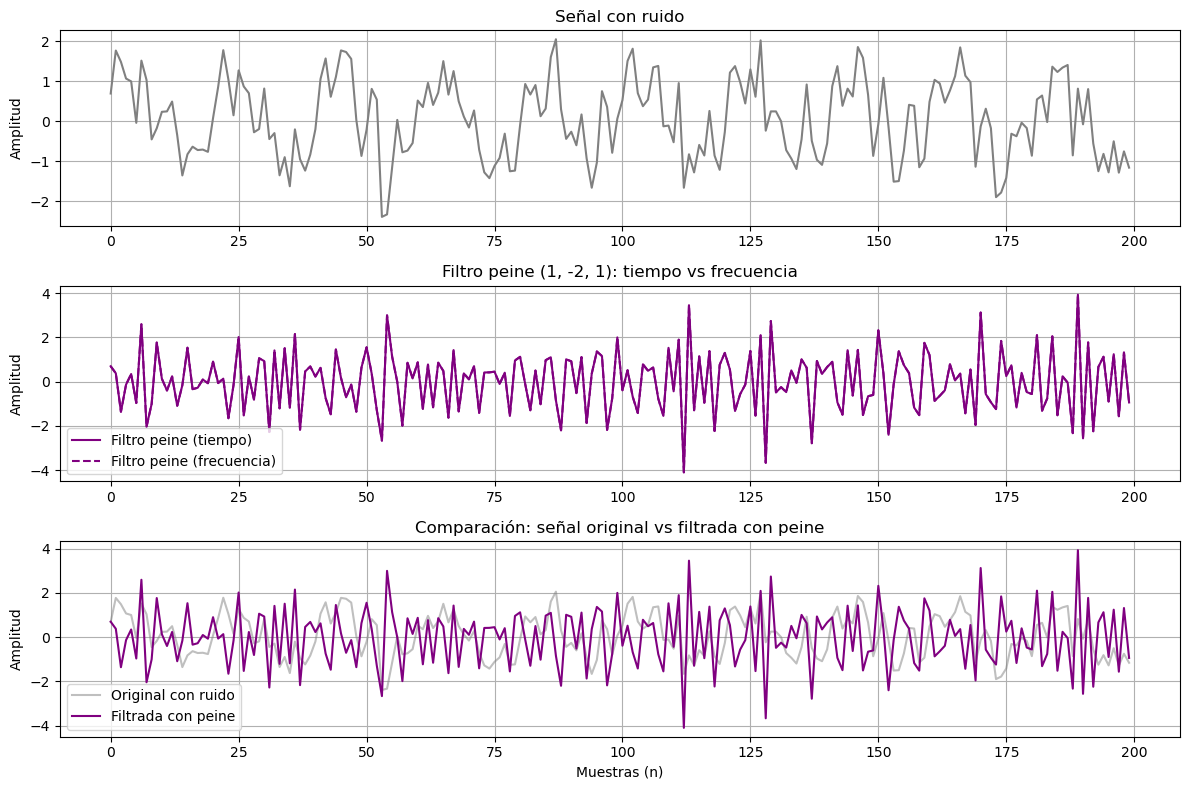

In [13]:
# Aplicamos el filtro peine a la señal con ruido
# Usamos ambos métodos: convolución temporal y convolución circular en frecuencia

y_peine_tiempo = filtrar_convolucion(senal_con_ruido, h_peine)[:len(senal_con_ruido)]
y_peine_freq   = filtrar_frecuencia(senal_con_ruido, h_peine)[:len(senal_con_ruido)]

# Comparamos temporal: señal original vs filtrada
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(senal_con_ruido[:200], label="Con ruido", color='gray')
axes[0].set_title("Señal con ruido")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)

axes[1].plot(y_peine_tiempo[:200], label="Filtro peine (tiempo)", color='purple')
axes[1].plot(y_peine_freq[:200],   label="Filtro peine (frecuencia)", color='purple', linestyle='--')
axes[1].set_title("Filtro peine (1, -2, 1): tiempo vs frecuencia")
axes[1].set_ylabel("Amplitud")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(senal_con_ruido[:200], label="Original con ruido", color='gray', alpha=0.5)
axes[2].plot(y_peine_tiempo[:200], label="Filtrada con peine", color='purple')
axes[2].set_title("Comparación: señal original vs filtrada con peine")
axes[2].set_xlabel("Muestras (n)")
axes[2].set_ylabel("Amplitud")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


### ANÁLISIS ESPECTRAL: EFECTO DEL FILTRO PEINE EN FRECUENCIA


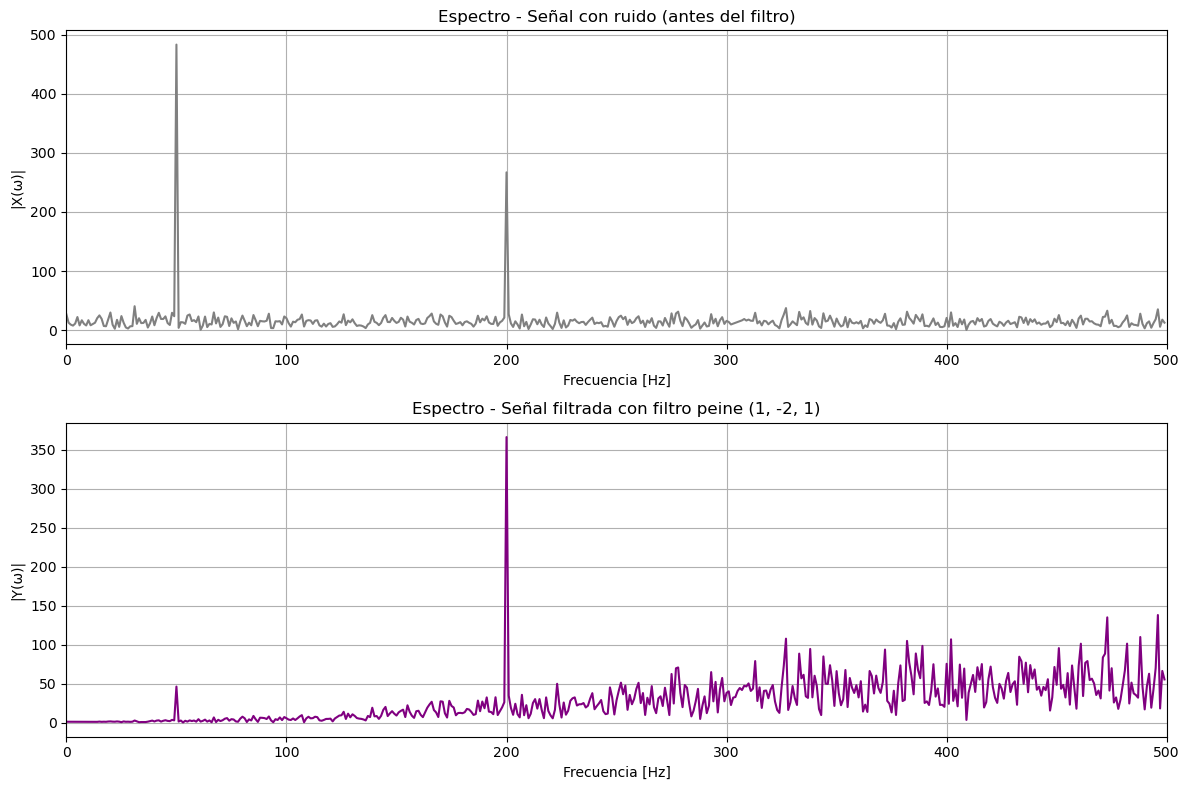

In [9]:
# Graficamos el espectro de la señal antes y después del filtrado
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Espectro original con ruido
X_original = np.fft.fft(senal_con_ruido)
freqs = np.fft.fftfreq(len(senal_con_ruido), d=1/fs)
mitad = len(senal_con_ruido) // 2

axes[0].plot(freqs[:mitad], np.abs(X_original[:mitad]), color='gray')
axes[0].set_title("Espectro - Señal con ruido (antes del filtro)")
axes[0].set_ylabel("|X(ω)|")
axes[0].set_xlabel("Frecuencia [Hz]")
axes[0].grid(True)
axes[0].set_xlim(0, 500)  # Limitamos para ver mejor

# Espectro señal filtrada
Y_peine = np.fft.fft(y_peine_tiempo)
axes[1].plot(freqs[:mitad], np.abs(Y_peine[:mitad]), color='purple')
axes[1].set_title("Espectro - Señal filtrada con filtro peine (1, -2, 1)")
axes[1].set_ylabel("|Y(ω)|")
axes[1].set_xlabel("Frecuencia [Hz]")
axes[1].grid(True)
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

### Observación: convolución temporal vs circular en frecuencia

**Efecto del filtrado:** el filtro peine h=[1,−2,1] modifica la señal de manera muy distinta al filtro media móvil. En lugar de suavizarla, resalta las variaciones rápidas y los cambios bruscos entre muestras consecutivas. Como consecuencia, la salida presenta oscilaciones más pronunciadas y una reducción importante de las componentes de baja frecuencia. En el espectro se aprecia que las frecuencias bajas son fuertemente atenuadas, mientras que las componentes más altas permanecen más visibles, evidenciando el carácter pasa-altos del filtro.

**Comparación entre métodos:** los resultados obtenidos mediante convolución directa y mediante procesamiento en frecuencia coinciden prácticamente muestra a muestra, lo que confirma la equivalencia entre ambos enfoques. El uso de zero-padding en la implementación con FFT permite evitar efectos de convolución circular no deseados y reproducir correctamente la convolución lineal del filtro FIR.

### 6. IDENTIFICACIÓN DE SISTEMA

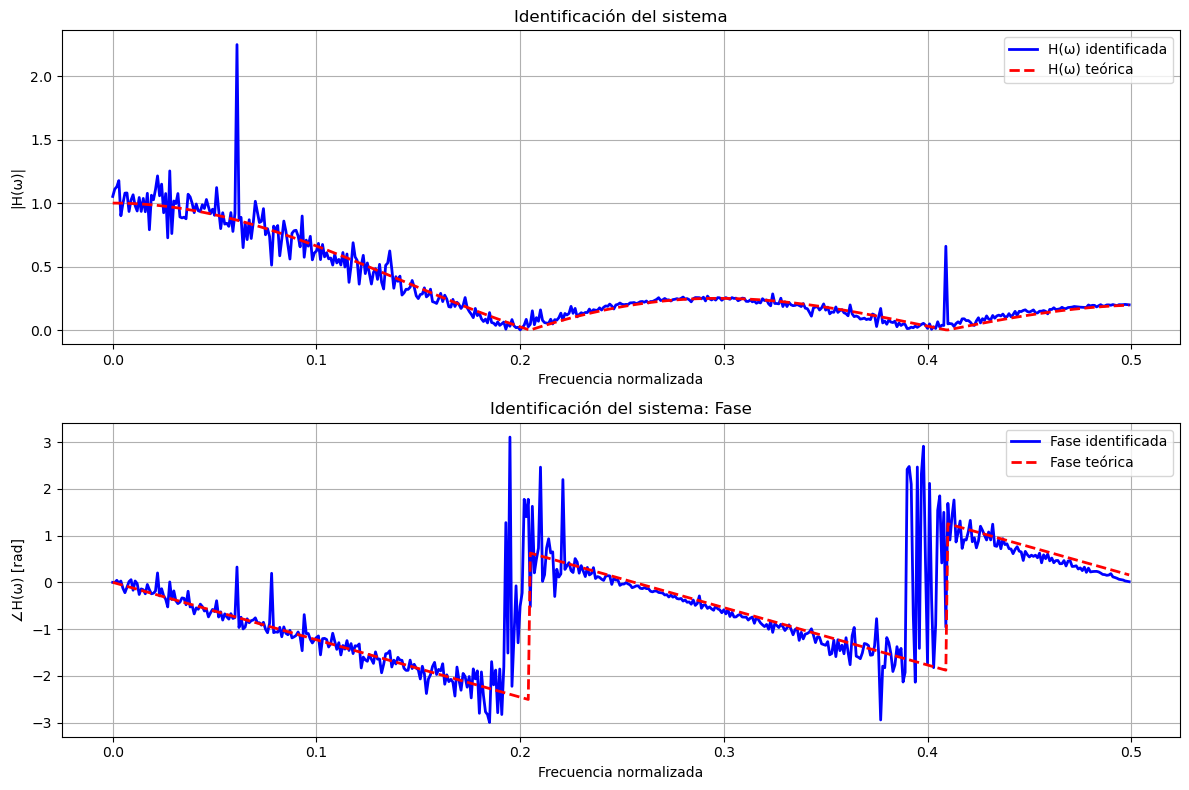

In [15]:
# Usamos el sistema media móvil M=5 como sistema a identificar
sistema_a_identificar = filtro_media_movil(5)

# Usamos la señal con ruido 
entrada = senal_con_ruido

# Calculamos la salida del sistema
salida = filtrar_convolucion(entrada, sistema_a_identificar)[:len(entrada)]

# Identificamos H(ω)
H_identificada, freqs_id = calcular_H(entrada, salida)

# Calculamos H(ω) teórica (comparación)
impulso = np.zeros(1024)
impulso[0] = 1
salida_teorica = filtrar_convolucion(impulso, sistema_a_identificar)[:1024]
H_teorica, _ = calcular_H(impulso, salida_teorica)

# Graficamos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
mitad = len(freqs_id) // 2

ax1.plot(freqs_id[:mitad], np.abs(H_identificada[:mitad]), 'b-', label="H(ω) identificada", linewidth=2)
ax1.plot(freqs_id[:mitad], np.abs(H_teorica[:mitad]), 'r--', label="H(ω) teórica", linewidth=2)
ax1.set_title("Identificación del sistema")
ax1.set_xlabel("Frecuencia normalizada")
ax1.set_ylabel("|H(ω)|")
ax1.legend()
ax1.grid(True)

ax2.plot(freqs_id[:mitad], np.angle(H_identificada[:mitad]), 'b-', label="Fase identificada", linewidth=2)
ax2.plot(freqs_id[:mitad], np.angle(H_teorica[:mitad]), 'r--', label="Fase teórica", linewidth=2)
ax2.set_title("Identificación del sistema: Fase")
ax2.set_xlabel("Frecuencia normalizada")
ax2.set_ylabel("∠H(ω) [rad]")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()